# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import sys
print(sys.executable)

c:\Users\jesur\miniconda3\envs\tf\python.exe


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

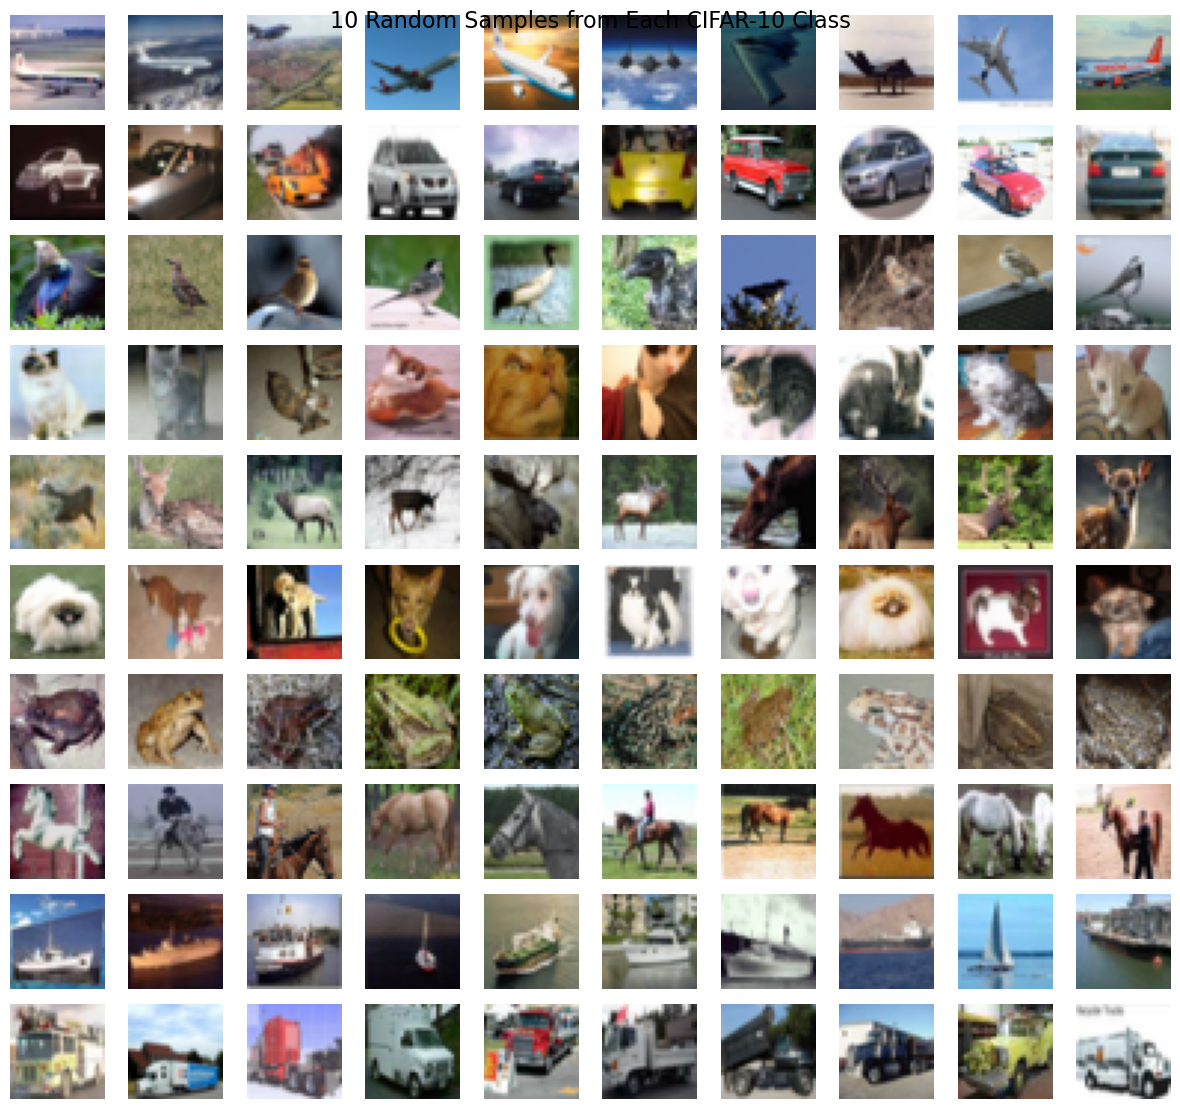

Original y_train shape:       (50000, 1)
One-hot y_train shape:        (50000, 10)
Example - first label (orig): [6]
Example - first label (one-hot): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

After normalization:
x_train_norm min / max: 0.0 1.0
x_train_norm dtype:     float32


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# 1. Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# ────────────────────────────────────────────────
# Task 1: Visualize 10 random samples from each class (10×10 grid)
# ────────────────────────────────────────────────

plt.figure(figsize=(12, 12))

for class_idx in range(10):
    # Find indices of images belonging to this class
    class_indices = np.where(y_train.flatten() == class_idx)[0]
    
    # Randomly select 10 images from this class
    selected = np.random.choice(class_indices, size=10, replace=False)
    
    for i, idx in enumerate(selected):
        plt.subplot(10, 10, class_idx * 10 + i + 1)
        plt.imshow(x_train[idx])
        plt.axis('off')
        
        # Show class name only on the leftmost column
        if i == 0:
            plt.ylabel(class_names[class_idx], fontsize=11, rotation=0, labelpad=40, va='center')

plt.suptitle("10 Random Samples from Each CIFAR-10 Class", fontsize=16, y=0.92)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ────────────────────────────────────────────────
# Task 2: Convert labels to one-hot encoded form
# ────────────────────────────────────────────────

y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot  = to_categorical(y_test,  num_classes=10)

# Verification
print("Original y_train shape:      ", y_train.shape)       # (50000, 1)
print("One-hot y_train shape:       ", y_train_onehot.shape) # (50000, 10)
print("Example - first label (orig):", y_train[0])           # e.g. [6]
print("Example - first label (one-hot):", y_train_onehot[0])

# ────────────────────────────────────────────────
# Task 3: Normalize the images (to [0,1] range)
# ────────────────────────────────────────────────

# Best practice: convert to float32 first, then divide
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Verification
print("\nAfter normalization:")
print("x_train_norm min / max:", x_train_norm.min(), x_train_norm.max())  # 0.0 1.0
print("x_train_norm dtype:    ", x_train_norm.dtype)                     # float32

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer. 

Use the input as (32,32,3). 

The filter maps can then be flattened to provide features to the classifier. 

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [4]:
from keras.backend import clear_session
clear_session()

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Definición del modelo
model = models.Sequential([
    # Frontal convolucional
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(32, 32, 3),
        padding='valid'   # por defecto, no se agrega padding
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),
    
    # Aplanar las características
    layers.Flatten(),
    
    # Clasificador
    layers.Dense(
        units=100,
        activation='relu'
    ),
    layers.Dense(
        units=10,                # 10 clases en CIFAR-10
        activation='softmax'
    )
])

# Mostrar el resumen del modelo
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 32)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 7200)              0         
                                                                 
 dense (Dense)               (None, 100)               720100    
                                                                 
 dense_1 (Dense)             (None, 10)                1010      
                                                                 
Total params: 722,006
Trainable params: 722,006
Non-trainable params: 0
__________________________________________________

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [6]:
# Your code here :
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np

# ────────────────────────────────────────────────
# 1. Cargar y preparar los datos (ya lo hicimos antes, pero lo repetimos por completitud)
# ────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalización [0,1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print("Datos listos → train:", x_train.shape, y_train.shape)
print("           → test :", x_test.shape,  y_test.shape)

# ────────────────────────────────────────────────
# 2. Definir el modelo (el mismo que antes)
# ────────────────────────────────────────────────
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

# ────────────────────────────────────────────────
# 3. Compilar el modelo EXACTAMENTE como se pide
# ────────────────────────────────────────────────
model.compile(
    optimizer='sgd',                    # SGD con parámetros por defecto
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Opcional: versión explícita (mismo resultado)
# from tensorflow.keras.optimizers import SGD
# model.compile(
#     optimizer=SGD(learning_rate=0.01, momentum=0.0, nesterov=False),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# ────────────────────────────────────────────────
# 4. Entrenar durante 50 épocas con batch_size=512
# ────────────────────────────────────────────────
print("\nEntrenando el modelo...\n")

history = model.fit(
    x_train, y_train,
    batch_size=512,
    epochs=50,
    validation_data=(x_test, y_test),
    verbose=1          # 1 = barra de progreso, 0 = silencioso, 2 = una línea por época
)

# ────────────────────────────────────────────────
# 5. (Opcional) Evaluar al final
# ────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nResultado final en test:")
print(f"  → Loss:     {test_loss:.4f}")
print(f"  → Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Datos listos → train: (50000, 32, 32, 3) (50000, 10)
           → test : (10000, 32, 32, 3) (10000, 10)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 7200)              0         
                                                                 
 dense_2 (Dense)             (None, 100)               720100    
                                                                 
 dense_3 (Dense)             (None, 10)                1010      
                                                                 
Total params: 72

*   Plot the cross entropy loss curve and the accuracy curve

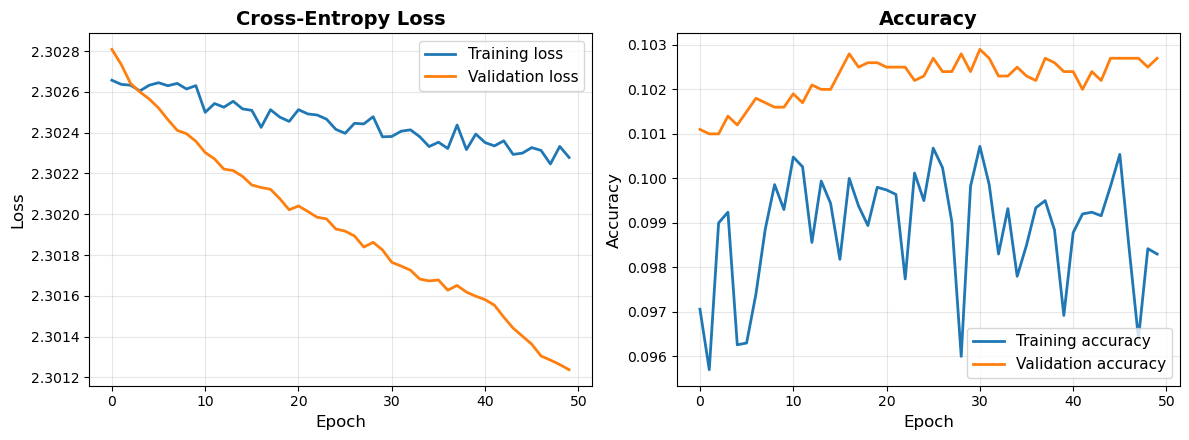

In [7]:
# Your code here :
import matplotlib.pyplot as plt

# Create figure with two subplots side by side
plt.figure(figsize=(12, 4.5))

# Plot 1: Loss curves
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation loss', linewidth=2)
plt.title('Cross-Entropy Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation accuracy', linewidth=2)
plt.title('Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3. 

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [8]:
from keras.backend import clear_session
clear_session()

Shape train: (50000, 32, 32, 3) (50000, 10)
Shape test : (10000, 32, 32, 3) (10000, 10)
Model: "VGG-like_CIFAR10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1_1 (Conv2D)            (None, 32, 32, 32)        896       
                                                                 
 conv1_2 (Conv2D)            (None, 32, 32, 32)        9248      
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 fc_128 (Dense)              (None, 128)               1048704   
                                                                 
 output (Dense)              (None, 10)                1290      
                            

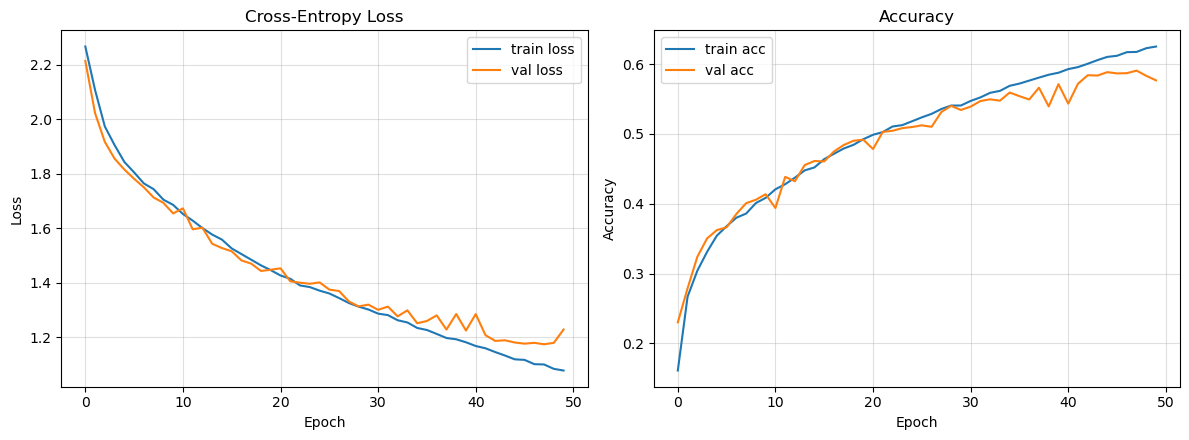

In [9]:
# Your code here :
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Limpiar sesión para evitar acumulación de grafos (buena práctica en notebooks)
tf.keras.backend.clear_session()

# ────────────────────────────────────────────────
# 1. Cargar y preparar CIFAR-10 (si no lo tienes ya)
# ────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print("Shape train:", x_train.shape, y_train.shape)
print("Shape test :", x_test.shape,  y_test.shape)

# ────────────────────────────────────────────────
# 2. Definir modelo VGG-like (más profundo que el anterior)
# ────────────────────────────────────────────────
model = models.Sequential(name="VGG-like_CIFAR10")

# Bloque 1: dos convoluciones 32 filtros + pooling
model.add(layers.Conv2D(32, (3, 3),
                         activation='relu',
                         padding='same',
                         input_shape=(32, 32, 3),
                         name='conv1_1'))
model.add(layers.Conv2D(32, (3, 3),
                         activation='relu',
                         padding='same',
                         name='conv1_2'))
model.add(layers.MaxPooling2D((2, 2), name='pool1'))

# Aplanar y clasificador
model.add(layers.Flatten(name='flatten'))
model.add(layers.Dense(128, activation='relu', name='fc_128'))
model.add(layers.Dense(10, activation='softmax', name='output'))

model.summary()

# ────────────────────────────────────────────────
# 3. Compilar (usamos lo mismo que antes para comparar)
# ────────────────────────────────────────────────
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ────────────────────────────────────────────────
# 4. Entrenar 50 épocas, batch 512
# ────────────────────────────────────────────────
print("\n=== Entrenando modelo VGG-like ===\n")

history = model.fit(
    x_train, y_train,
    batch_size=512,
    epochs=50,
    validation_data=(x_test, y_test),
    verbose=1
)

# ────────────────────────────────────────────────
# 5. Evaluación final
# ────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

# ────────────────────────────────────────────────
# 6. Gráficas de loss y accuracy
# ────────────────────────────────────────────────
plt.figure(figsize=(12, 4.5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.4)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

Loading CIFAR-10...
Train shape: (50000, 32, 32, 3), labels: (50000, 10)
Test  shape: (10000, 32, 32, 3),  labels: (10000, 10)
Model: "VGG-like_CIFAR10_simplificado"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 32, 32, 32)        896       
                                                                 
 conv2 (Conv2D)              (None, 32, 32, 32)        9248      
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense_128 (Dense)           (None, 128)               1048704   
                                                                 
 output (Dense)              (None, 10)   

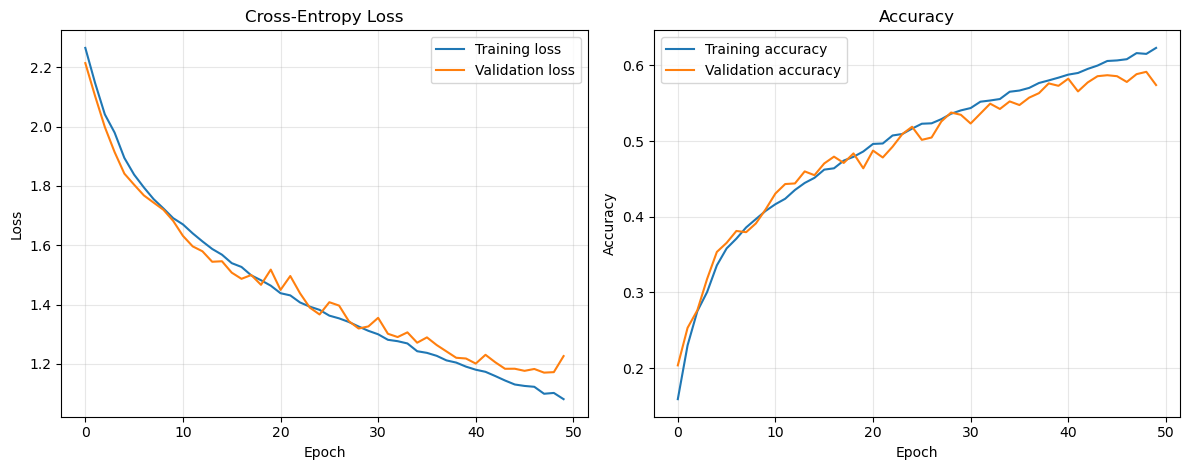

In [10]:
# Your code here :
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Optional: clear any previous Keras session (good practice in notebooks)
tf.keras.backend.clear_session()

# ────────────────────────────────────────────────
# 1. Load & prepare CIFAR-10 (run only once)
# ────────────────────────────────────────────────
print("Loading CIFAR-10...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize to [0,1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print(f"Train shape: {x_train.shape}, labels: {y_train.shape}")
print(f"Test  shape: {x_test.shape},  labels: {y_test.shape}")

# ────────────────────────────────────────────────
# 2. Re-create the model (exactly as described)
# ────────────────────────────────────────────────
model = models.Sequential(name="VGG-like_CIFAR10_simplificado")

# Block 1: two conv layers with same padding
model.add(layers.Conv2D(
    32, (3, 3),
    activation='relu',
    padding='same',
    input_shape=(32, 32, 3),
    name='conv1'
))
model.add(layers.Conv2D(
    32, (3, 3),
    activation='relu',
    padding='same',
    name='conv2'
))
model.add(layers.MaxPooling2D((2, 2), name='pool1'))

# Flatten + classifier
model.add(layers.Flatten(name='flatten'))
model.add(layers.Dense(128, activation='relu', name='dense_128'))
model.add(layers.Dense(10, activation='softmax', name='output'))

model.summary()

# ────────────────────────────────────────────────
# 3. Compile exactly as requested
# ────────────────────────────────────────────────
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled with:")
print("• Optimizer: SGD (default parameters)")
print("• Loss:      categorical_crossentropy")
print("• Metric:    accuracy\n")

# ────────────────────────────────────────────────
# 4. Train for 50 epochs, batch size 512
# ────────────────────────────────────────────────
print("Starting training (50 epochs, batch=512)...\n")

history = model.fit(
    x_train, y_train,
    batch_size=512,
    epochs=50,
    validation_data=(x_test, y_test),
    verbose=1
)

# ────────────────────────────────────────────────
# 5. Final evaluation
# ────────────────────────────────────────────────
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

# ────────────────────────────────────────────────
# 6. Plot loss and accuracy curves
# ────────────────────────────────────────────────
plt.figure(figsize=(12, 4.8))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.
 

Training shallow model...
Epoch 1/50
98/98 [==============================] - 3s 18ms/step - loss: 2.3027 - accuracy: 0.1008 - val_loss: 2.3023 - val_accuracy: 0.0975
Epoch 2/50
98/98 [==============================] - 1s 13ms/step - loss: 2.3028 - accuracy: 0.0980 - val_loss: 2.3021 - val_accuracy: 0.0993
Epoch 3/50
98/98 [==============================] - 1s 13ms/step - loss: 2.3027 - accuracy: 0.0961 - val_loss: 2.3021 - val_accuracy: 0.0976
Epoch 4/50
98/98 [==============================] - 1s 14ms/step - loss: 2.3026 - accuracy: 0.0987 - val_loss: 2.3020 - val_accuracy: 0.1025
Epoch 5/50
98/98 [==============================] - 1s 14ms/step - loss: 2.3026 - accuracy: 0.0990 - val_loss: 2.3019 - val_accuracy: 0.0991
Epoch 6/50
98/98 [==============================] - 1s 14ms/step - loss: 2.3026 - accuracy: 0.0991 - val_loss: 2.3019 - val_accuracy: 0.1014
Epoch 7/50
98/98 [==============================] - 1s 14ms/step - loss: 2.3025 - accuracy: 0.0968 - val_loss: 2.3017 - val_accu

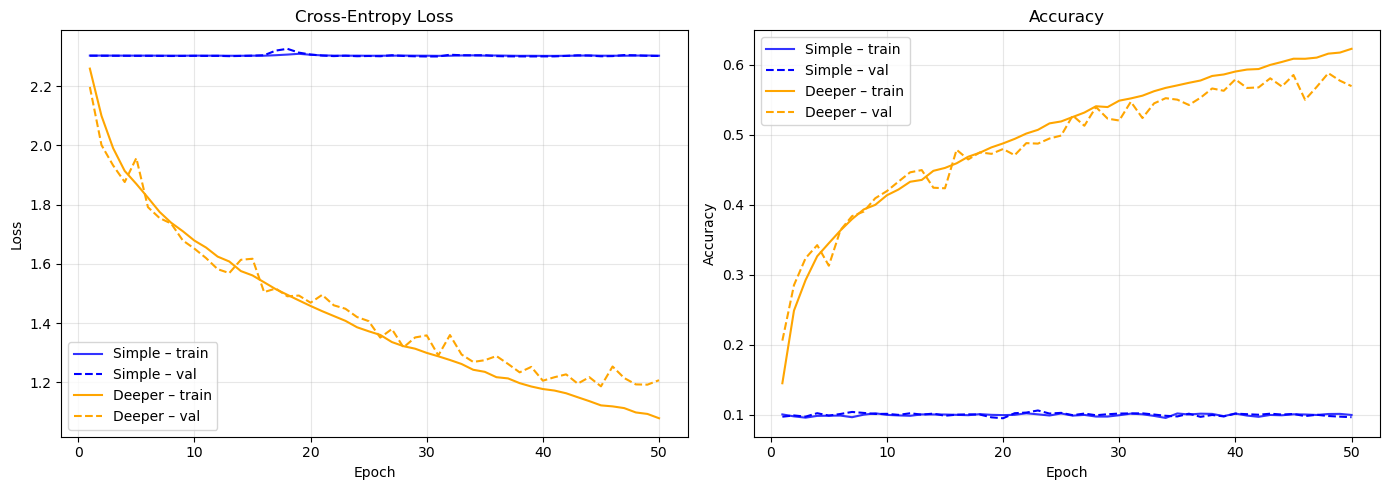


Final test performance:
Simple model → acc = 0.1620
Deeper model → acc = 0.5697


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Clear any old state
tf.keras.backend.clear_session()

# Load data (only once)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

# ────────────────────────────────
# Model 1: Shallow (single conv)
# ────────────────────────────────
model_simple = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_simple.compile(optimizer='sgd',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

print("Training shallow model...")
history_simple = model_simple.fit(x_train, y_train,
                                  batch_size=512,
                                  epochs=50,
                                  validation_data=(x_test, y_test),
                                  verbose=1)

# ────────────────────────────────
# Model 2: Deeper (VGG-like)
# ────────────────────────────────
model_deeper = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_deeper.compile(optimizer='sgd',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

print("\nTraining deeper model...")
history_deeper = model_deeper.fit(x_train, y_train,
                                  batch_size=512,
                                  epochs=50,
                                  validation_data=(x_test, y_test),
                                  verbose=1)

# ────────────────────────────────
# Now plot comparison
# ────────────────────────────────
epochs = range(1, 51)

plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, history_simple.history['loss'],     label='Simple – train', color='blue', alpha=0.8)
plt.plot(epochs, history_simple.history['val_loss'], label='Simple – val',   color='blue', linestyle='--')
plt.plot(epochs, history_deeper.history['loss'],     label='Deeper – train', color='orange')
plt.plot(epochs, history_deeper.history['val_loss'], label='Deeper – val',   color='orange', linestyle='--')
plt.title('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, history_simple.history['accuracy'],     label='Simple – train', color='blue', alpha=0.8)
plt.plot(epochs, history_simple.history['val_accuracy'], label='Simple – val',   color='blue', linestyle='--')
plt.plot(epochs, history_deeper.history['accuracy'],     label='Deeper – train', color='orange')
plt.plot(epochs, history_deeper.history['val_accuracy'], label='Deeper – val',   color='orange', linestyle='--')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final test accuracies
print("\nFinal test performance:")
print(f"Simple model → acc = {model_simple.evaluate(x_test, y_test, verbose=0)[1]:.4f}")
print(f"Deeper model → acc = {model_deeper.evaluate(x_test, y_test, verbose=0)[1]:.4f}")

**Comment on the observation**

*(Double-click or enter to edit)*
the double model has a better performace than the older one
...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


Loading CIFAR-10 test set...
Test images: (10000, 32, 32, 3), True labels: (10000,)

Making predictions on test set...
20/20 [==============================] - 0s 11ms/step
Manual accuracy from predictions: 0.5740 (57.40%)


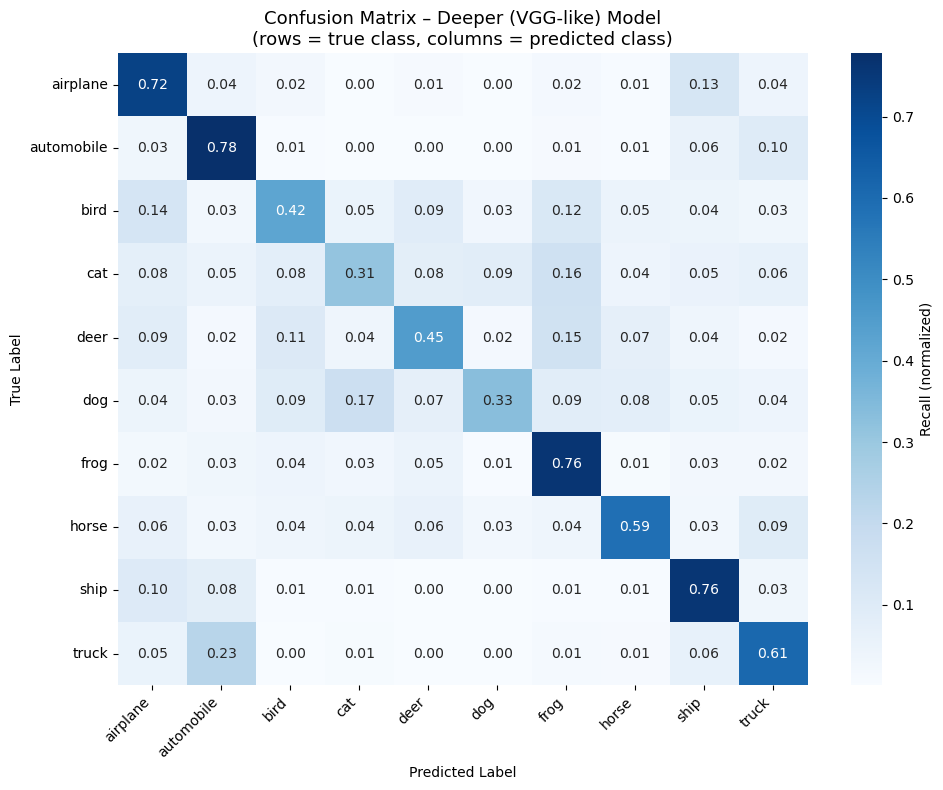


Most common confusions (normalized recall ≥ 0.15 off-diagonal):
  cat        → frog       : 0.159
  deer       → frog       : 0.155
  dog        → cat        : 0.171
  truck      → automobile : 0.229


In [14]:
# Your code here :
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# ────────────────────────────────────────────────
# 1. Load test data (if not already in memory)
# ────────────────────────────────────────────────
print("Loading CIFAR-10 test set...")
(_, _), (x_test, y_test_true) = cifar10.load_data()

# Normalize (must match training preprocessing)
x_test = x_test.astype('float32') / 255.0

# True labels (integer form 0–9)
y_true = y_test_true.flatten()          # shape (10000,)

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print(f"Test images: {x_test.shape}, True labels: {y_true.shape}")

# ────────────────────────────────────────────────
# 2. Get predictions from the deeper model
# ────────────────────────────────────────────────
print("\nMaking predictions on test set...")
y_pred_prob = model.predict(x_test, batch_size=512, verbose=1)   # shape (10000, 10)

# Get predicted class (argmax)
y_pred = np.argmax(y_pred_prob, axis=1)                          # shape (10000,)

# Quick accuracy check (should match model.evaluate)
accuracy = np.mean(y_pred == y_true)
print(f"Manual accuracy from predictions: {accuracy:.4f} ({accuracy*100:.2f}%)")

# ────────────────────────────────────────────────
# 3. Compute and plot confusion matrix
# ────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, normalize='true')   # normalized rows = recall per class

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Recall (normalized)'})

plt.title('Confusion Matrix – Deeper (VGG-like) Model\n(rows = true class, columns = predicted class)', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# 4. (Optional) Print most confused pairs (off-diagonal > 0.15)
# ────────────────────────────────────────────────
print("\nMost common confusions (normalized recall ≥ 0.15 off-diagonal):")
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] >= 0.15:
            print(f"  {class_names[i]:10} → {class_names[j]:10} : {cm[i,j]:.3f}")

**Comment here :**

*(Double-click or enter to edit)*

...

*    Print the test accuracy for the trained model.

In [15]:

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")

Test accuracy: 0.5740  (57.40%)


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer. 

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling. 

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer. 

For all the layers, use ReLU activation function. 

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [15]:
from keras.backend import clear_session
clear_session()

In [16]:
# Your code here :
import tensorflow as tf
from tensorflow.keras import layers, models

# Clear previous session (recommended in notebooks)
tf.keras.backend.clear_session()

# ────────────────────────────────────────────────
# Deeper VGG-inspired model with 64×64 input
# ────────────────────────────────────────────────
model = models.Sequential(name="VGG_like_CIFAR10_64x64")

# Input shape explicitly set
model.add(layers.Input(shape=(64, 64, 3)))

# Block 1: 2 × Conv 64
model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv1_1'))
model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv1_2'))
model.add(layers.MaxPooling2D((2, 2), name='pool1'))           # 64→32

# Block 2: 2 × Conv 128
model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv2_1'))
model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv2_2'))
model.add(layers.MaxPooling2D((2, 2), name='pool2'))           # 32→16

# Block 3: 2 × Conv 256
model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu', name='conv3_1'))
model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu', name='conv3_2'))
model.add(layers.MaxPooling2D((2, 2), name='pool3'))           # 16→8

# Classifier head
model.add(layers.Flatten(name='flatten'))
model.add(layers.Dense(128, activation='relu', name='fc_128'))
model.add(layers.Dense(10, activation='softmax', name='output'))

# Show model architecture
model.summary()

Model: "VGG_like_CIFAR10_64x64"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1_1 (Conv2D)            (None, 64, 64, 64)        1792      
                                                                 
 conv1_2 (Conv2D)            (None, 64, 64, 64)        36928     
                                                                 
 pool1 (MaxPooling2D)        (None, 32, 32, 64)        0         
                                                                 
 conv2_1 (Conv2D)            (None, 32, 32, 128)       73856     
                                                                 
 conv2_2 (Conv2D)            (None, 32, 32, 128)       147584    
                                                                 
 pool2 (MaxPooling2D)        (None, 16, 16, 128)       0         
                                                                 
 conv3_1 (Conv2D)            (None, 16, 16, 

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [1]:
# Your code here :
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ────────────────────────────────────────────────
# 1. Clear session & define the model (64×64 input)
# ────────────────────────────────────────────────
tf.keras.backend.clear_session()

model = models.Sequential(name="VGG_like_64x64")

model.add(layers.Input(shape=(64, 64, 3)))

# Block 1: 64 filters
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Block 2: 128 filters
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Block 3: 256 filters
model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Classifier
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

# ────────────────────────────────────────────────
# 2. Load + resize CIFAR-10 to 64×64
# ────────────────────────────────────────────────
print("Loading and resizing CIFAR-10...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train_resized = tf.image.resize(x_train, [64, 64], method='bilinear')
x_test_resized  = tf.image.resize(x_test,  [64, 64], method='bilinear')

x_train_resized = x_train_resized / 255.0
x_test_resized  = x_test_resized  / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print("Train shape:", x_train_resized.shape)   # (50000, 64, 64, 3)
print("Test shape :", x_test_resized.shape)    # (10000, 64, 64, 3)

# ────────────────────────────────────────────────
# 3. Compile (exactly as requested)
# ────────────────────────────────────────────────
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ────────────────────────────────────────────────
# 4. Train for 10 epochs, batch 512
# ────────────────────────────────────────────────
print("\nTraining for 10 epochs...")
history = model.fit(
    x_train_resized, y_train,
    batch_size=512,
    epochs=10,
    validation_data=(x_test_resized, y_test),
    verbose=1
)

# Quick final evaluation
_, test_acc = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"\nTest accuracy after 10 epochs: {test_acc:.4f} ({test_acc*100:.2f}%)")

# ────────────────────────────────────────────────
# 5. Predict on test set
# ────────────────────────────────────────────────
print("\nPredicting on test set...")
y_pred_prob = model.predict(x_test_resized, batch_size=512, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)   # or y_test.flatten() if not one-hot

# ────────────────────────────────────────────────
# 6. Confusion Matrix
# ────────────────────────────────────────────────
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Recall (row-normalized)'})

plt.title('Confusion Matrix – 64×64 VGG-like model (10 epochs)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# 7. Print notable confusions (off-diagonal ≥ 0.15)
# ────────────────────────────────────────────────
print("\nNotable class confusions (≥ 15% of true class predicted as another):")
for i in range(10):
    for j in range(10):
        if i != j and cm[i,j] >= 0.15:
            print(f"  {class_names[i]:10}  →  {class_names[j]:10} : {cm[i,j]:.3f}")

Model: "VGG_like_64x64"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 64)        1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32, 32, 64)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 32, 32, 128)       147584    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 16, 16, 128)      0         
 2D)                                                

NotFoundError: Graph execution error:

Detected at node 'gradient_tape/VGG_like_64x64/conv2d_5/Conv2D/Conv2DBackpropInput' defined at (most recent call last):
    File "c:\Users\jesur\miniconda3\envs\tf\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Users\jesur\miniconda3\envs\tf\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "c:\Users\jesur\miniconda3\envs\tf\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "c:\Users\jesur\miniconda3\envs\tf\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "c:\Users\jesur\miniconda3\envs\tf\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "c:\Users\jesur\miniconda3\envs\tf\lib\site-packages\tornado\platform\asyncio.py", line 211, in start
      self.asyncio_loop.run_forever()
    File "c:\Users\jesur

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:



the made an linear regression in each layer, so with activation model the model can only learn linear relationships

2 - Key Differences between sigmoid and softmax:



_Because in sigmoid each class is independent(is a bird? yes/no), and in the other hand on softmax, the classses are mutually excluded by each other, they made the questions of is it a cat, dog bird, etc.... and only one result

3 - Key Differences between categorical crossentropy and binary crossentropy loss:

one is for 2 clases and the other one is for multiple classes
_
